### Trabajo Final: Aplicación de Módulos y Paquetes en Python para Machine Learning en un Contexto Empresarial

**Caso práctico:** Empresa de análisis de datos financieros — clasificación de opiniones (positivas/negativas) y predicción de tendencias de mercado.

**Librerías requeridas **
```
pip install pandas numpy scikit-learn matplotlib seaborn spacy nltk transformers torch tensorflow
python -m spacy download es_core_news_sm
```
En Python, también ejecutar una vez:
```python
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
```

In [ ]:
!pip install spacy
!python -m spacy download es_core_news_sm

  Using cached https://github.com/explosion/spacy-models/releases/download/es_core_news_sm-3.8.0/es_core_news_sm-3.8.0-py3-none-any.whl (12.9 MB)
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 1. Manipulación y análisis de datos con Pandas y Numpy

Carga del dataset de opiniones (`opiniones_financieras.csv`) y del dataset de serie de tiempo (`tendencia_mercado.csv`).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.sparse import hstack

import spacy

sns.set_style("whitegrid")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ENTREGABLE/opiniones_financieras.csv")
print(df.shape)
df.head()

(240, 3)


,texto,sentimiento,num_palabras
0,el fondo de inversion tiene una plataforma muy...,positivo,13
1,"Excelente atencion al cliente, la cooperativa ...",positivo,11
2,El equipo de la casa de bolsa fue muy profesio...,positivo,16
3,Estoy feliz con la rentabilidad que me ha dado...,positivo,14
4,Estoy feliz con la rentabilidad que me ha dado...,positivo,15


In [ ]:
# Exploración básica con Pandas/Numpy
print(df.info())
print("\nDistribución de clases:")
print(df["sentimiento"].value_counts())
print("\nEstadísticos de num_palabras:")
print(df["num_palabras"].describe())

# Transformación: variable binaria (0 = negativo, 1 = positivo)
df["label"] = np.where(df["sentimiento"] == "positivo", 1, 0)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   texto         240 non-null    object
 1   sentimiento   240 non-null    object
 2   num_palabras  240 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 5.8+ KB
None

Distribución de clases:
sentimiento
positivo    120
negativo    120
Name: count, dtype: int64

Estadísticos de num_palabras:
count    240.000000
mean      12.875000
std        1.804515
min        9.000000
25%       12.000000
50%       13.000000
75%       14.000000
max       17.000000
Name: num_palabras, dtype: float64


,texto,sentimiento,num_palabras,label
0,el fondo de inversion tiene una plataforma muy...,positivo,13,1
1,"Excelente atencion al cliente, la cooperativa ...",positivo,11,1
2,El equipo de la casa de bolsa fue muy profesio...,positivo,16,1
3,Estoy feliz con la rentabilidad que me ha dado...,positivo,14,1
4,Estoy feliz con la rentabilidad que me ha dado...,positivo,15,1


## 2. Preprocesamiento NLP (spaCy) + escalado de variables numéricas (StandardScaler)

Se limpia y lematiza el texto con spaCy (igual que en los talleres previos) y se escala la variable numérica `num_palabras` con `StandardScaler`, tal como pide el entregable.

In [ ]:
nlp = spacy.load("es_core_news_sm")

def limpiar_lematizar(texto):
    doc = nlp(texto.lower())
    tokens = [t.lemma_ for t in doc if t.is_alpha and not t.is_stop]
    return " ".join(tokens)

df["texto_limpio"] = df["texto"].apply(limpiar_lematizar)
df[["texto", "texto_limpio"]].head()

,texto,texto_limpio
0,el fondo de inversion tiene una plataforma muy...,fondo inversion plataforma intuitivo facil
1,"Excelente atencion al cliente, la cooperativa ...",excelente atencion cliente cooperativa resolvi...
2,El equipo de la casa de bolsa fue muy profesio...,equipo casa bolsa profesional explicar yo opci...
3,Estoy feliz con la rentabilidad que me ha dado...,feliz rentabilidad entidad crediticio trimestre
4,Estoy feliz con la rentabilidad que me ha dado...,feliz rentabilidad fondo inversion trimestre


In [ ]:
X_train_txt, X_test_txt, y_train, y_test, num_train, num_test = train_test_split(
    df["texto_limpio"], df["label"], df[["num_palabras"]],
    test_size=0.2, random_state=42, stratify=df["label"]
)

# TF-IDF sobre el texto (ajustado SOLO con train)
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train_txt)
X_test_tfidf = vectorizer.transform(X_test_txt)

# StandardScaler sobre la variable numérica (ajustado SOLO con train)
scaler = StandardScaler()
num_train_scaled = scaler.fit_transform(num_train)
num_test_scaled = scaler.transform(num_test)

# Combinar features de texto (TF-IDF) + feature numérica escalada
X_train_final = hstack([X_train_tfidf, num_train_scaled])
X_test_final = hstack([X_test_tfidf, num_test_scaled])

print("Shape train:", X_train_final.shape, " Shape test:", X_test_final.shape)

Shape train: (192, 102)  Shape test: (48, 102)


## 3. Modelo de clasificación (Scikit-learn) — validación del modelo

In [ ]:
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train_final, y_train)

y_pred = modelo.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, target_names=["negativo", "positivo"]))

Accuracy: 1.0

Reporte de clasificación:
               precision    recall  f1-score   support

    negativo       1.00      1.00      1.00        24
    positivo       1.00      1.00      1.00        24

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



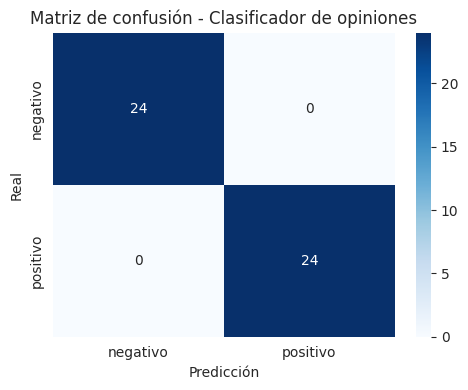

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negativo", "positivo"], yticklabels=["negativo", "positivo"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Clasificador de opiniones")
plt.tight_layout()
plt.savefig("matriz_confusion.png", dpi=150)
plt.show()

## 3.1 Prueba con nuevas opiniones (extracción de info de reportes / análisis de sentimiento)

In [ ]:
nuevas_opiniones = [
    "El servicio al cliente del banco fue rapido y muy profesional, me encantó",
    "La plataforma se cayo justo cuando iba a vender mis acciones, pesimo ",
    "Estoy conforme con la rentabilidad obtenida este mes, buen servicio",
    "Nunca mas invierto con esta fintech, perdi dinero por sus comisiones ocultas"
]

nuevas_limpias = [limpiar_lematizar(t) for t in nuevas_opiniones]
nuevas_tfidf = vectorizer.transform(nuevas_limpias)
nuevas_num = scaler.transform(pd.DataFrame({"num_palabras": [len(t.split()) for t in nuevas_opiniones]}))
nuevas_final = hstack([nuevas_tfidf, nuevas_num])

predicciones = modelo.predict(nuevas_final)
for texto, pred in zip(nuevas_opiniones, predicciones):
    print(f"{texto!r} -> {'positivo' if pred == 1 else 'negativo'}")

'El servicio al cliente del banco fue rapido y muy profesional, me encantó' -> positivo
'La plataforma se cayo justo cuando iba a vender mis acciones, pesimo ' -> negativo
'Estoy conforme con la rentabilidad obtenida este mes, buen servicio' -> negativo
'Nunca mas invierto con esta fintech, perdi dinero por sus comisiones ocultas' -> negativo


## 4. Análisis de sentimiento con Transformers (alternativa/comparación con el modelo clásico)

Se usa un modelo preentrenado en español para comparar contra el modelo TF-IDF + Logistic Regression.

In [ ]:
import torch
from transformers import pipeline

analizador = pipeline(
    "sentiment-analysis",
    model="pysentimiento/robertuito-sentiment-analysis",
    device=-1
)

resultados_transformers = analizador(nuevas_opiniones)
for texto, res in zip(nuevas_opiniones, resultados_transformers):
    print(f"{texto!r} -> {res['label']} ({res['score']:.2f})")

config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  435MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

'El servicio al cliente del banco fue rapido y muy profesional' -> POS (0.95)
'La plataforma se cayo justo cuando iba a vender mis acciones, pesimo' -> NEG (0.97)
'Estoy conforme con la rentabilidad obtenida este mes' -> POS (0.94)
'Nunca mas invierto con esta fintech, perdi dinero por sus comisiones ocultas' -> NEG (0.94)


## 5. Deep Learning (TensorFlow/Keras): red neuronal para predecir tendencia de mercado (serie de tiempo)

In [ ]:
df_ts = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ENTREGABLE/tendencia_mercado.csv", parse_dates=["fecha"])
df_ts.head()

,fecha,precio_cierre,retorno_diario,media_movil_10,tendencia
0,2023-01-02,100.54,0.00000,NaN,baja
1,2023-01-03,100.44,-0.00099,NaN,baja
2,2023-01-04,101.13,0.00687,NaN,alza
3,2023-01-05,102.71,0.01562,NaN,alza
4,2023-01-06,102.51,-0.00195,NaN,baja


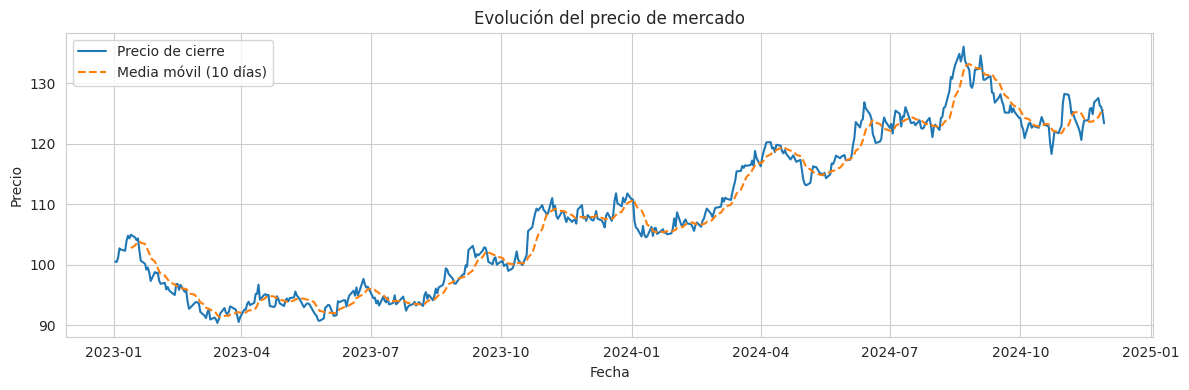

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(df_ts["fecha"], df_ts["precio_cierre"], label="Precio de cierre")
plt.plot(df_ts["fecha"], df_ts["media_movil_10"], label="Media móvil (10 días)", linestyle="--")
plt.title("Evolución del precio de mercado")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.tight_layout()
plt.savefig("tendencia_mercado.png", dpi=150)
plt.show()

In [ ]:
# Preparar ventanas de tiempo (usar los últimos N días para predecir el siguiente precio)
precios = df_ts["precio_cierre"].values.astype("float32")

scaler_ts = StandardScaler()
precios_scaled = scaler_ts.fit_transform(precios.reshape(-1, 1)).flatten()

N = 10  # tamaño de ventana
X_seq, y_seq = [], []
for i in range(len(precios_scaled) - N):
    X_seq.append(precios_scaled[i:i+N])
    y_seq.append(precios_scaled[i+N])
X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

split = int(len(X_seq) * 0.8)
X_train_ts, X_test_ts = X_seq[:split], X_seq[split:]
y_train_ts, y_test_ts = y_seq[:split], y_seq[split:]

print("Train:", X_train_ts.shape, " Test:", X_test_ts.shape)

Train: (392, 10)  Test: (98, 10)


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

modelo_nn = keras.Sequential([
    layers.Input(shape=(N,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)  # regresión: predice el siguiente precio (escalado)
])

modelo_nn.compile(optimizer="adam", loss="mse", metrics=["mae"])
modelo_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
historial = modelo_nn.fit(
    X_train_ts, y_train_ts,
    validation_data=(X_test_ts, y_test_ts), # 50 epocas
    epochs=50, batch_size=16, verbose=1
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.1040 - mae: 0.2384 - val_loss: 0.1195 - val_mae: 0.3043
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0221 - mae: 0.1159 - val_loss: 0.0459 - val_mae: 0.1702
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0176 - mae: 0.1010 - val_loss: 0.0587 - val_mae: 0.2090
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0154 - mae: 0.0936 - val_loss: 0.0378 - val_mae: 0.1560
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0136 - mae: 0.0885 - val_loss: 0.0338 - val_mae: 0.1500
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0122 - mae: 0.0836 - val_loss: 0.0272 - val_mae: 0.1296
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0110 - mae: 0.0801 - val_loss: 0.0265 - val_mae: 0.1321
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0106 - mae: 0.0796 - val_loss: 0.0230 - val_mae: 0.1184
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0097 - ma

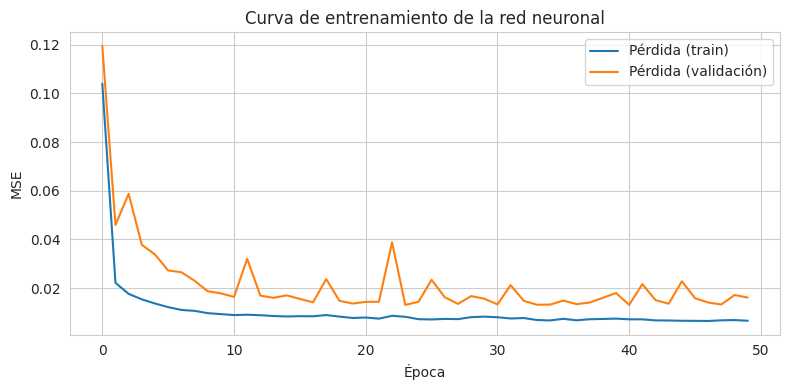

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(historial.history["loss"], label="Pérdida (train)")
plt.plot(historial.history["val_loss"], label="Pérdida (validación)")
plt.title("Curva de entrenamiento de la red neuronal")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.savefig("curva_entrenamiento.png", dpi=150)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


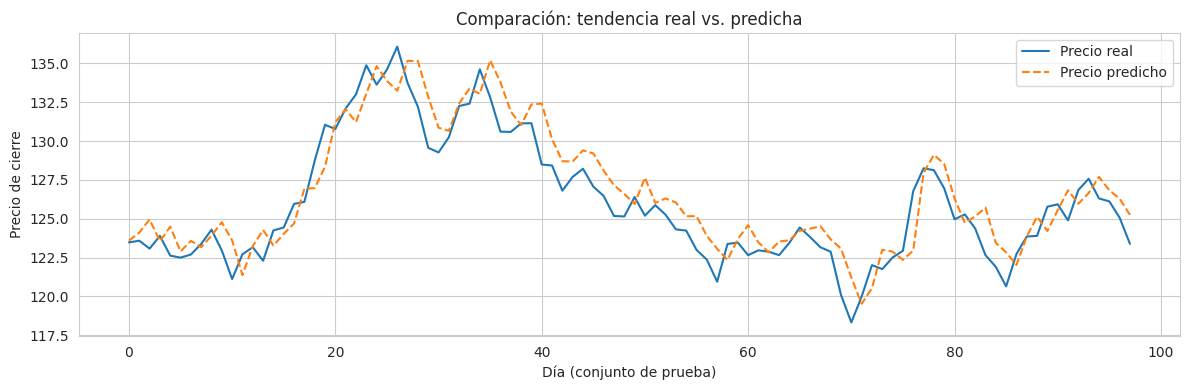

In [ ]:
y_pred_ts = modelo_nn.predict(X_test_ts).flatten()

# Volver a la escala original de precios
y_test_real = scaler_ts.inverse_transform(y_test_ts.reshape(-1, 1)).flatten()
y_pred_real = scaler_ts.inverse_transform(y_pred_ts.reshape(-1, 1)).flatten()

plt.figure(figsize=(12, 4))
plt.plot(y_test_real, label="Precio real")
plt.plot(y_pred_real, label="Precio predicho", linestyle="--")
plt.title("Comparación: tendencia real vs. predicha")
plt.xlabel("Día (conjunto de prueba)")
plt.ylabel("Precio de cierre")
plt.legend()
plt.tight_layout()
plt.savefig("prediccion_vs_real.png", dpi=150)
plt.show()

## 6. Gráficos comparativos adicionales (histogramas, dispersión, líneas de tendencia)

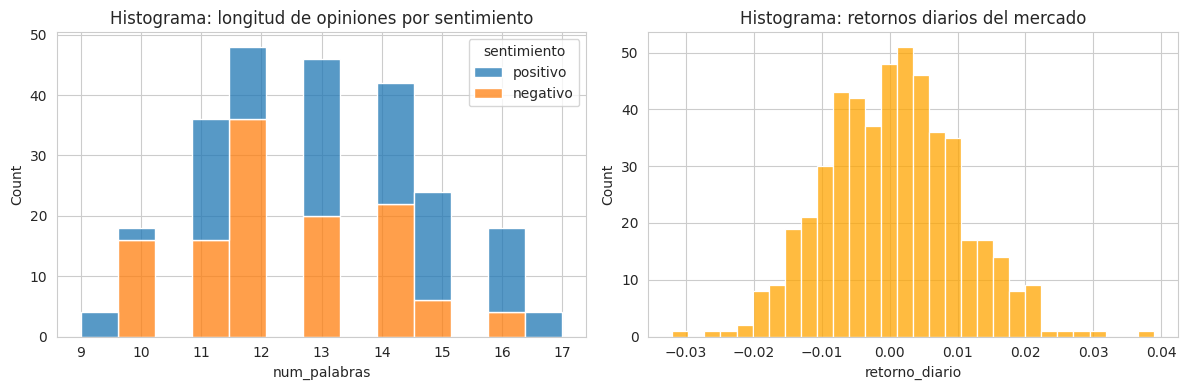

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma: longitud de las opiniones por clase
sns.histplot(data=df, x="num_palabras", hue="sentimiento", multiple="stack", ax=axes[0])
axes[0].set_title("Histograma: longitud de opiniones por sentimiento")

# Histograma: retornos diarios del mercado
sns.histplot(df_ts["retorno_diario"], bins=30, ax=axes[1], color="orange")
axes[1].set_title("Histograma: retornos diarios del mercado")

plt.tight_layout()
plt.savefig("histogramas.png", dpi=150)
plt.show()

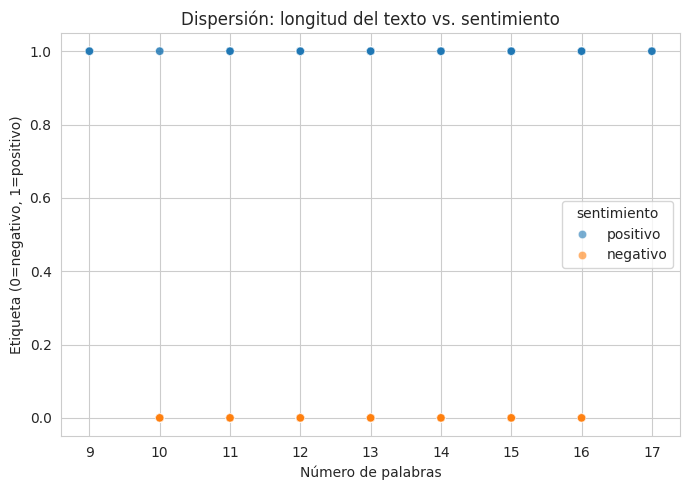

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="num_palabras", y="label", hue="sentimiento", alpha=0.6)
plt.title("Dispersión: longitud del texto vs. sentimiento")
plt.xlabel("Número de palabras")
plt.ylabel("Etiqueta (0=negativo, 1=positivo)")
plt.tight_layout()
plt.savefig("dispersion.png", dpi=150)
plt.show()